In [9]:
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# (x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()


In [4]:
import pickle
import os
import numpy as np


def load_cifar10_custom(data_dir):

    def unpickle(file):
        with open(file, 'rb') as fo:
            dict = pickle.load(fo, encoding='bytes')
        return dict

    train_data = []
    train_labels = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(data_dir, f'data_batch_{i}'))
        train_data.append(batch[b'data'])
        train_labels.extend(batch[b'labels'])

    x_train = np.concatenate(train_data).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_train = np.array(train_labels).reshape(-1, 1)

    test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
    x_test = test_batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y_test = np.array(test_batch[b'labels']).reshape(-1, 1)

    return (x_train, y_train), (x_test, y_test)


path = r'C:\Mohsen Folder\Ai Bootcamp\Ai Bootcamp\notebooks\Project\6. HW_L04_01_Deep_Learning\data\cifar-10-batches-py'
(x_train, y_train), (x_test, y_test) = load_cifar10_custom(path)


In [5]:
# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0



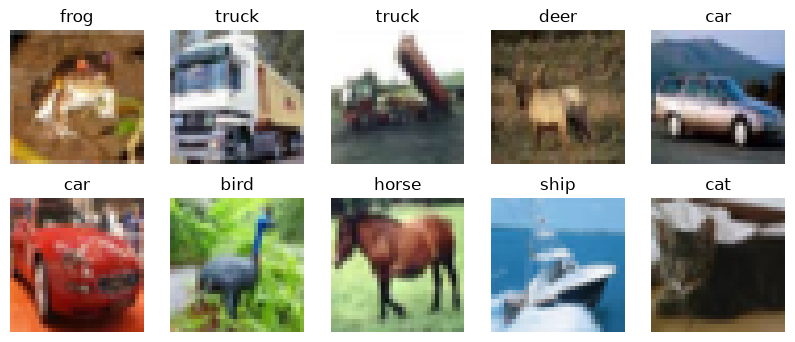

In [7]:
# Show some samples
class_names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

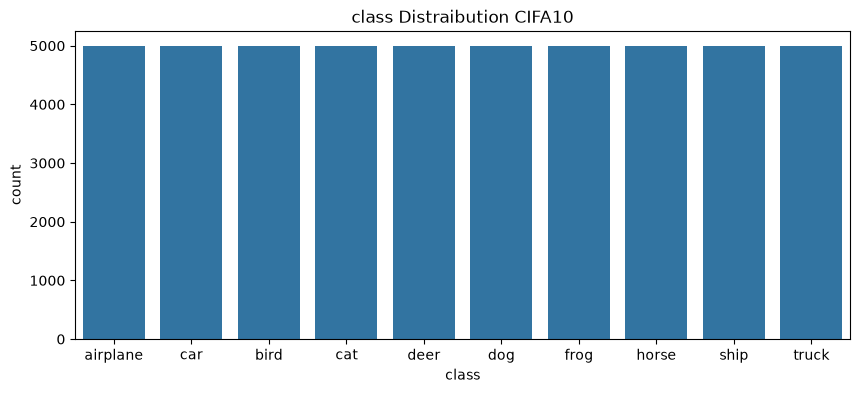

In [13]:
unique , conunt = np.unique(y_train, return_counts=True)


plt.figure(figsize=(10,4))

sns.barplot(x=class_names, y = conunt)
plt.title("class Distraibution CIFA10")
plt.xlabel("class")
plt.ylabel("count")
plt.show()

In [ ]:
from tensorflow.keras import layers, models

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


In [ ]:
model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 95ms/step - accuracy: 0.2526 - loss: 2.0008 - val_accuracy: 0.4418 - val_loss: 1.5290
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.4299 - loss: 1.5873 - val_accuracy: 0.5188 - val_loss: 1.3688
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 96ms/step - accuracy: 0.4819 - loss: 1.4399 - val_accuracy: 0.5342 - val_loss: 1.3599
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 96ms/step - accuracy: 0.5168 - loss: 1.3609 - val_accuracy: 0.5948 - val_loss: 1.1578
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5419 - loss: 1.3079 - val_accuracy: 0.5908 - val_loss: 1.1865
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5550 - loss: 1.2565 - val_accuracy: 0.6224 - val_loss: 1.0616
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5716 - loss: 1.2209 - val_accuracy: 0.6192 - val_loss: 1.0722
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.5877 - loss: 1.1836 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6675 - loss: 0.9527
Test accuracy: 0.6668000221252441


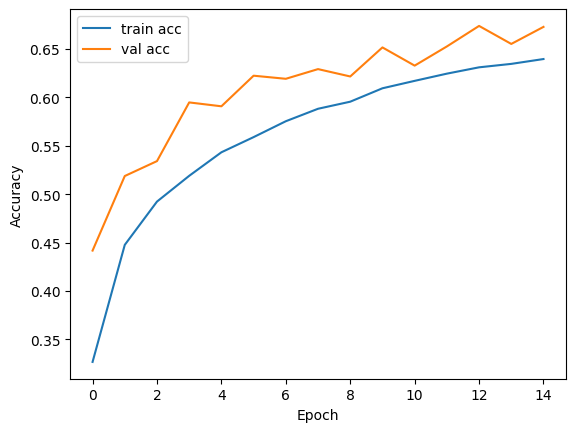

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# Plot accuracy curves
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


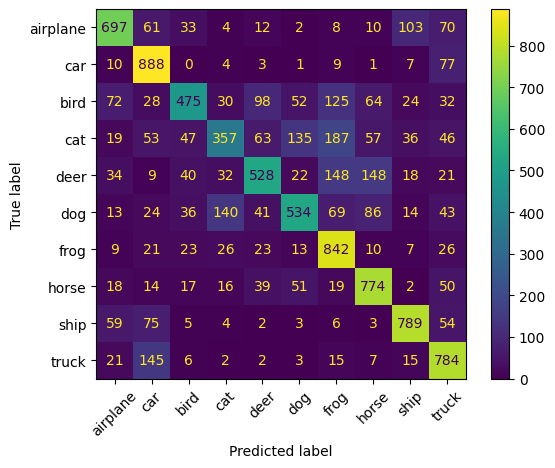

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names, xticks_rotation=45)
plt.show()
